# Compte-Rendu de Travaux Pratiques : Équations Différentielles Ordinaires et Résolution Numérique

## Introduction

Ce projet a été réalisé dans le cadre de ma Licence Double-Diplôme Mathématiques et Économie à l'Université Paris-Saclay. Il présente un compte-rendu de synthèse des méthodes numériques explorées lors des trois séances de Travaux Pratiques de l'UE, ainsi que le projet d'épidémiologie sur lequel j'ai travaillé pour l'évaluation finale.

La qualité du travail et des implémentations présentées ici a permis de valider cette unité d'enseignement avec d'excellents résultats :
- **Note au TP noté : 19,5/20**
- **Note finale de l'UE : 17/20**

## TP 1 : Champs de vecteurs et courbes intégrales

**Intérêt pédagogique :** L'étude d'un champ de vecteurs est primordiale pour visualiser géométriquement et comprendre de manière qualitative le comportement des solutions d'un système différentiel (les courbes intégrales). Cela permet d'identifier l'allure des trajectoires sans nécessairement disposer de l'expression analytique exacte de la solution.

*Attention :* Dans la partie théorique et la modélisation associée, il est primordial de faire attention au signe de la dérivée $z'(t)$. Il ne faut surtout pas oublier le signe "-" qui s'y trouve normalement. C'est une erreur classique qui modifie complètement la dynamique du système !

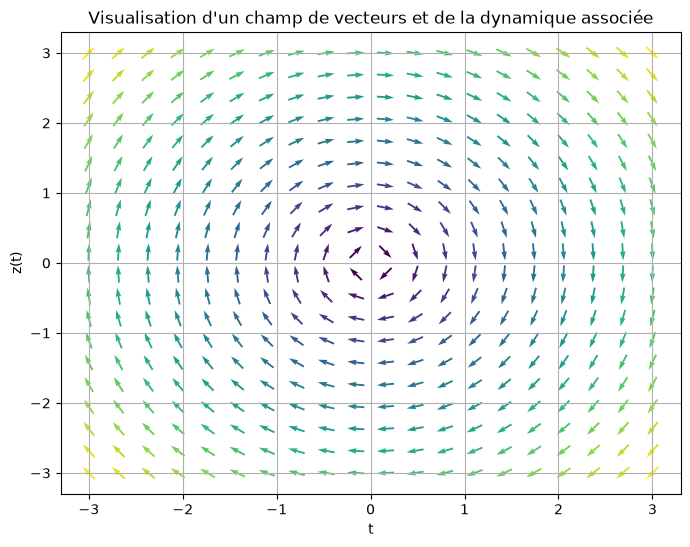

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Définition de la grille spatiale
t = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
T, Y = np.meshgrid(t, y)

# Champ de vecteurs générique illustrant des trajectoires périodiques / tourbillonnaires
U = Y
V = -T

# Normalisation du champ pour un affichage uniforme et clair
norm = np.sqrt(U**2 + V**2)
norm[norm == 0] = 1 # Prévention de division par zéro au centre
U_n = U / norm
V_n = V / norm

plt.figure(figsize=(8, 6))
plt.quiver(T, Y, U_n, V_n, norm, cmap='viridis', pivot='mid')
plt.title("Visualisation d'un champ de vecteurs et de la dynamique associée")
plt.xlabel("t")
plt.ylabel("z(t)")
plt.grid(True)

plt.show()

## TP 2 : Oscillateur harmonique et schéma d'Euler Symplectique

**Intérêt de la méthode :** Le schéma d'Euler Symplectique est la méthode numérique de choix pour l'intégration des systèmes hamiltoniens, tel que l'oscillateur harmonique. L'approche classique (Euler explicite) introduit une création artificielle d'énergie à chaque pas de temps, ce qui fait diverger rapidement les solutions oscillantes. L'Euler Symplectique, au contraire, conserve exactement une "énergie modifiée" très proche de l'énergie physique réelle. Cette propriété garantit une excellente stabilité à long terme et la préservation géométrique des orbites fermées du système.

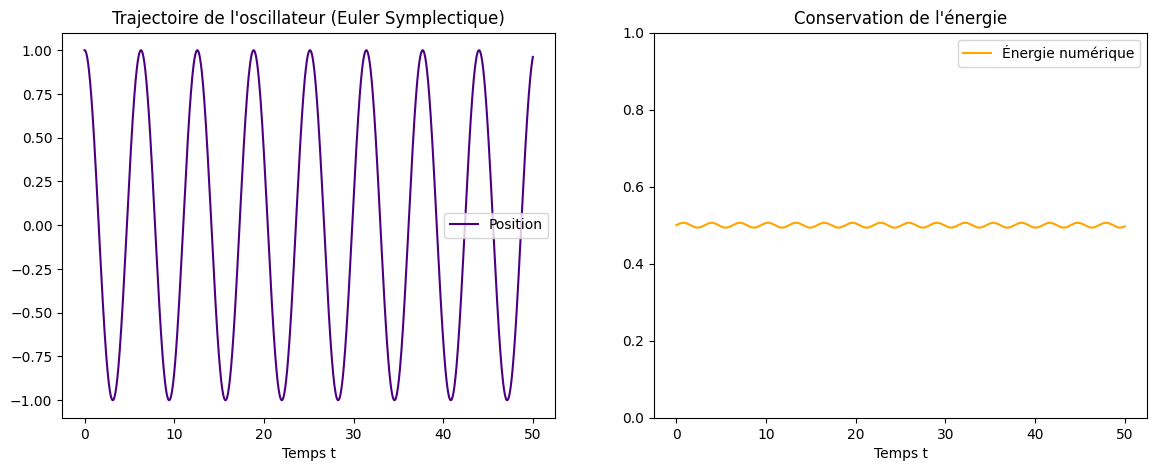

In [5]:
# Implementation du schéma d'Euler symplectique
def euler_symplectique(t0, tf, X0, N, omega=1.0):
    t = np.linspace(t0, tf, N)
    h = t[1] - t[0]

    Y = np.zeros((N, 2))
    Y[0] = X0
    for n in range(N - 1):
        Y[n+1, 0] = Y[n, 0] + h * Y[n, 1]
        Y[n+1, 1] = Y[n, 1] - h * (omega**2) * Y[n+1, 0]
    return t, Y

t, Y_sol = euler_symplectique(0, 50, np.array([1.0, 0.0]), 2000)

energie = 0.5 * Y_sol[:, 1]**2 + 0.5 * Y_sol[:, 0]**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t, Y_sol[:, 0], color='indigo', label='Position')
axes[0].set_title('Trajectoire de l\'oscillateur (Euler Symplectique)')
axes[0].set_xlabel('Temps t')
axes[0].legend()
axes[1].plot(t, energie, color='orange', label='Énergie numérique')
axes[1].set_title("Conservation de l\'énergie")
axes[1].set_xlabel('Temps t')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.show()

## TP 3 : Équation de la chaleur et schéma de Crank-Nicolson

**Intérêt de la méthode :** Le schéma de Crank-Nicolson est optimal pour le traitement des Équations aux Dérivées Partielles (EDP) de type parabolique. C'est un schéma implicite inconditionnellement stable et d'ordre 2 en temps et en espace. Son implémentation via `scipy.sparse` permet d'inverser le système tridiagonal de manière extrêmement optimisée et rapide.

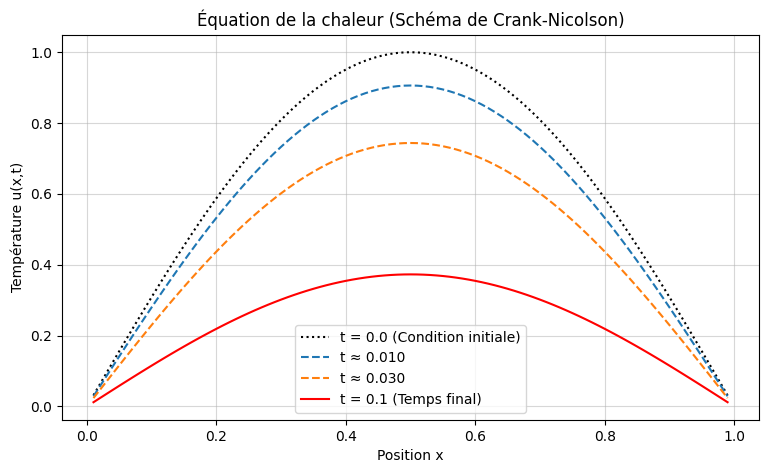

In [6]:
from scipy.sparse import diags, eye, csc_matrix
from scipy.sparse.linalg import spsolve

def crank_nicolson(U0, A, nu, dt, T):
    N = len(U0)
    U = U0.copy()
    t = 0.0

    I = eye(N, format='csc')
    A_sp = csc_matrix(A)

    M_impl = I - (nu * dt / 2) * A_sp
    M_expl = I + (nu * dt / 2) * A_sp
    solutions = [U.copy()]

    while t < T - 1e-12:
        dt_eff = min(dt, T - t)
        if dt_eff != dt:
            M_impl = I - (nu * dt_eff / 2) * A_sp
            M_expl = I + (nu * dt_eff / 2) * A_sp

        rhs = M_expl @ U
        U = spsolve(M_impl, rhs)
        solutions.append(U.copy())
        t += dt_eff

    return solutions

N_pts = 99
dx = 1.0 / (N_pts + 1)
x = np.linspace(dx, 1 - dx, N_pts)
nu = 1.0
dt = 0.005
T_final = 0.1

diagonals = [-2 * np.ones(N_pts), np.ones(N_pts - 1), np.ones(N_pts - 1)]
A = diags(diagonals, [0, -1, 1]).toarray() / dx**2

U0 = np.sin(np.pi * x)
sols = crank_nicolson(U0, A, nu, dt, T_final)

plt.figure(figsize=(9, 5))
plt.plot(x, sols[0], 'k:', label='t = 0.0 (Condition initiale)')
plt.plot(x, sols[int(len(sols)*0.1)], '--', label=f't ≈ {0.1 * T_final:.3f}')
plt.plot(x, sols[int(len(sols)*0.3)], '--', label=f't ≈ {0.3 * T_final:.3f}')
plt.plot(x, sols[-1], 'r-', label=f't = {T_final} (Temps final)')
plt.title('Équation de la chaleur (Schéma de Crank-Nicolson)')
plt.xlabel('Position x')
plt.ylabel('Température u(x,t)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## TP Noté : Modélisation Épidémiologique (Dynamique des Populations)

**Intérêt du modèle :** Pour modéliser la propagation d'une maladie, nous avons implémenté une extension du célèbre modèle SIR en y ajoutant une quatrième catégorie essentielle. Il s'agit du modèle **SEIR**, qui divise la population $N$ en quatre compartiments :
1. **S (Susceptibles)** : Les individus sains non infectés, vulnérables à la maladie.
2. **E (Exposés)** : Les individus en période d'incubation (contaminés mais pas encore infectieux).
3. **I (Infectieux/Infectés)** : Les individus malades capables de transmettre le pathogène.
4. **R (Rétablis/Convalescents)** : Les individus guéris et immunisés.

Ce système d'équations différentielles ordinaires non-linéaires met en évidence l'importance du traitement numérique (via `scipy.integrate.solve_ivp` par exemple) car il n'admet généralement pas de solution analytique explicite. L'analyse des courbes permet notamment de visualiser le "pic épidémique" et d'évaluer l'impact des paramètres de contagion.

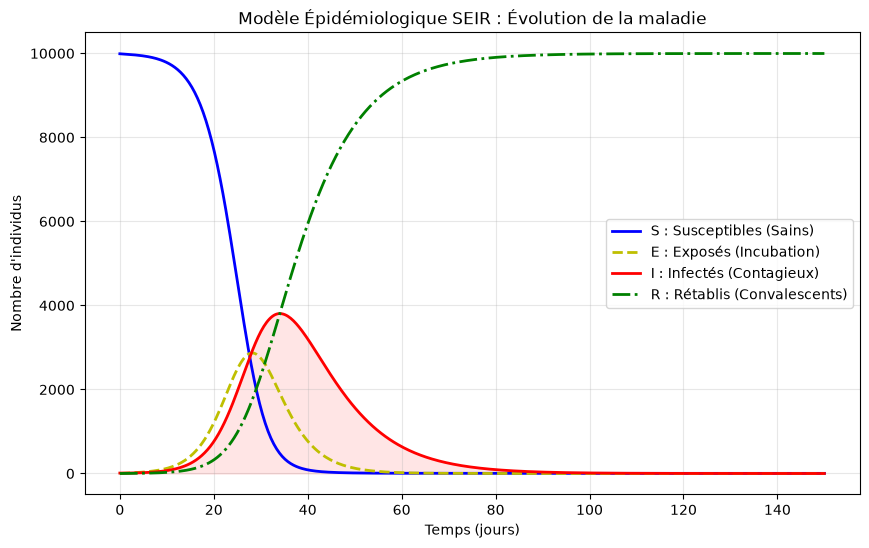

In [ ]:
from scipy.integrate import solve_ivp

# Paramètres du modèle épidémiologique SEIR
N = 10000      # Population totale
beta = 0.8     # Taux de transmission (contacts infectieux)
sigma = 0.2    # Taux d'incubation (1/temps moyen d'incubation)
gamma = 0.1    # Taux de guérison (1/temps moyen d'infection)

# Conditions initiales
I0 = 10        # 10 infectés initiaux
E0 = 0         # 0 exposé initialement
R0 = 0         # 0 rétabli initialement
S0 = N - I0 - E0 - R0 # Le reste de la population est susceptible
y0 = [S0, E0, I0, R0]

# Intervalle de temps (ex: 150 jours)
t_span = (0, 150)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Définition du système différentiel (Fonction vectorielle)
def seir_model(t, y):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

# Résolution numérique avec la méthode RK45 (Runge-Kutta)
solution = solve_ivp(seir_model, t_span, y0, t_eval=t_eval, method='RK45')

# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], 'b-', linewidth=2, label='S : Susceptibles (Sains)')
plt.plot(solution.t, solution.y[1], 'y--', linewidth=2, label='E : Exposés (Incubation)')
plt.plot(solution.t, solution.y[2], 'r-', linewidth=2, label='I : Infectés (Contagieux)')
plt.plot(solution.t, solution.y[3], 'g-.', linewidth=2, label='R : Rétablis (Convalescents)')

plt.title('Modèle Épidémiologique SEIR : Évolution de la maladie')
plt.xlabel('Temps (jours)')
plt.ylabel('Nombre d\'individus')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.fill_between(solution.t, solution.y[2], color='red', alpha=0.1) # Mise en valeur du pic épidémique
plt.show()